# Cross-validated held-out PySR predictions

This notebook only plots the held-out predictions from each CV fold:

- Regression: observed vs predicted pKd, colored by fold, annotated with fold Pearson r/RMSE.
- Classification: ROC curve for each fold, annotated with fold AUC/accuracy.

It reads existing CSVs from `plots_cv`; it does not train any models.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import accuracy_score, auc, roc_curve, r2_score

sns.set_context("paper")

reg_pred = pd.read_csv("/Users/erikhartman/dev/immunopeptides/plots_cv/regression/cv_predictions.csv")
class_pred = pd.read_csv("/Users/erikhartman/dev/immunopeptides/plots_cv/classification/cv_predictions.csv")

In [31]:
classification_fold_metrics = []
for fold, fold_df in class_pred.groupby("fold"):
    valid = fold_df[["y_true", "symbolic_pred", "symbolic_proba"]].replace([np.inf, -np.inf], np.nan).dropna()
    fpr, tpr, _ = roc_curve(valid["y_true"], valid["symbolic_proba"])
    classification_fold_metrics.append({
        "fold": fold,
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc(fpr, tpr),
        "accuracy": accuracy_score(valid["y_true"], valid["symbolic_pred"]),
        "n": len(valid),
    })
classification_fold_metrics = pd.DataFrame(classification_fold_metrics)

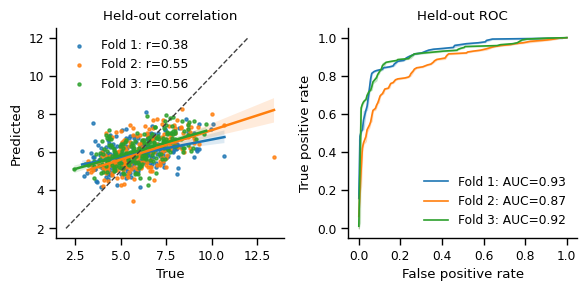

In [32]:
palette = sns.color_palette("tab10", n_colors=max(reg_pred["fold"].nunique(), class_pred["fold"].nunique()))
fold_colors = {fold: palette[i] for i, fold in enumerate(sorted(set(reg_pred["fold"]) | set(class_pred["fold"])))}

fig, axes = plt.subplots(1, 2, figsize=(6,3))

rs = []
ax = axes[0]
r2s = []
for fold, fold_df in reg_pred.groupby("fold"):
    valid = fold_df[["y_true", "symbolic_pred"]].replace([np.inf, -np.inf], np.nan).dropna()
    r = pearsonr(valid["y_true"], valid["symbolic_pred"]).statistic
    r2 = r2_score(valid["y_true"], valid["symbolic_pred"])
    r2s.append(r2)
    sns.regplot(
        x=fold_df["y_true"],
        y=fold_df["symbolic_pred"],
        label=f"Fold {fold}: r={r:.2f}",
        scatter_kws={"s":5},
        ax=ax
    )
    rs.append(r)

ax.plot([2,12],[2,12], color="0.25", linewidth=1, linestyle="--")
ax.legend(frameon=False)
ax.set_xlabel("True")
ax.set_ylabel("Predicted")
ax.set_title("Held-out correlation")

aucs = []
ax = axes[1]
for row in classification_fold_metrics.itertuples(index=False):
    sns.lineplot(
        x=row.fpr,
        y=row.tpr,
        color=fold_colors[row.fold],
        label=f"Fold {int(row.fold)}: AUC={row.auc:.2f}",
        ax=ax
    )
    aucs.append(row.auc)

ax.set_title("Held-out ROC")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")

ax.legend(frameon=False)
sns.despine()
plt.tight_layout()

In [33]:
print(np.mean(rs), np.std(rs))
print(np.mean(r2s), np.std(r2s))
print(np.mean(aucs), np.std(aucs))

0.49908697867153423 0.08190059437562672
0.24566661675680476 0.07728192768108577
0.9056513662554985 0.026731270934477646
